In [1]:
# prepare dataset
import utils.Config as Config
import tensorflow as tf
import utils.gestureDataLoader as gestureDataLoader
from sklearn.model_selection import train_test_split
from ATKMethods import *
gpus = tf.config.experimental.list_physical_devices( 'GPU' )
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth( gpu, True )
    except RuntimeError as e:
        print( e )
config = Config.getconfig( )
config.source = 'lab_276'
tf.config.experimental_run_functions_eagerly(True)
assert config.source != None, 'source should not be None'
train_data, test_data, train_label, test_label = gestureDataLoader.getData(
        config, 'signfi'
        )
X_train, X_test, y_train, y_test = train_test_split( train_data, train_label, test_size=0.1, random_state=42)
batch_size = config.batch_size
# load model
path = 'Surrogate_model_lab.h5'  
net = AlexNetTF( config )
model = net.buildModel( choice = 'defult')
model.load_weights(os.path.join('SavedModel/Adversarial_robust_model',path))
# model.summary()


2023-10-06 10:02:13.664152: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-10-06 10:02:13.798258: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2023-10-06 10:02:13.865938: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2023-10-06 10:02:14.228027: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: li

Instructions for updating:
Use `tf.config.run_functions_eagerly` instead of the experimental version.


2023-10-06 10:02:15.009805: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-10-06 10:02:15.045436: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-10-06 10:02:15.045561: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero


Loading data................


2023-10-06 10:02:28.933660: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-10-06 10:02:28.934901: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-10-06 10:02:28.935033: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-10-06 10:02:28.935083: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA

In [ ]:
from matplotlib import pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes
from mpl_toolkits.axes_grid1.inset_locator import mark_inset
import numpy as np
delta = gen_adv_data(x = test_data[0:1],
                    y = test_label[0:1],
                    model = model,
                    atk_type = 'fgsm',
                    psr = 0.0001,
                    targeted = False,
                    
                    )
# plt.plot(test_data[0,:,5,0])
adv = test_data[0:1] + delta
# plt.plot(adv[0,:,5,0])
fsize = 14
fig, ax = plt.subplots(figsize=(8, 5))


ax.plot(test_data[0,:,5,0], label = 'Clean')
ax.plot(adv[0,:,5,0], label = 'Adversarial')
ax.legend(fontsize = fsize)
# set ticks size
ax.tick_params(axis='both', which='major', labelsize=fsize)
# plt.xticks(np.linspace(0,2,200))
x_de = np.linspace(95, 100, 6).astype(int)
y_de = adv[0,:,5,0][x_de]

sub_axes = plt.axes([.2, .7, .15, .15]) 

# plot the zoomed portion
sub_axes.plot(x_de, test_data[0,:,5,0][x_de],) 
sub_axes.plot(x_de, adv[0,:,5,0][x_de],) 
#set the x and y limit
ax.set_ylim(0.35, 1)
#set the x and y label
ax.set_xlabel('Sampling point', fontsize = fsize)
ax.set_ylabel('Amplitude', fontsize = fsize)
mark_inset(ax, sub_axes, loc1=3, loc2=1, fc="lightslategrey", ec='0.5', alpha = 0.7,ls = '--')
ax.grid()
# plt.figure( figsize = (8, 5) )

# plt.xticks( fontsize=fsize )
# plt.yticks( fontsize=fsize )
plt.grid()
plt.savefig('RESULTS_FIGS/compare_wave_form.pdf', bbox_inches='tight')
plt.show()
#save to pdf
# out = 
# plt.savefig( out + '.pdf',bbox_inches='tight',  )


# White-box Attacks

# Black-box Attacks

#### compare_deepfool_PGD_FGSM.pdf

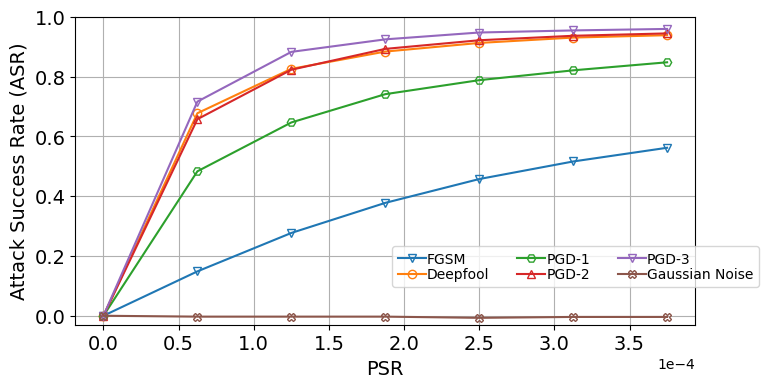

In [3]:
from Pub_plots import *
'''Plots the FGSM vs DeepFool vs PGD vs Gaussian noise'''

plot(
        pdf_name = 'compare_deepfool_PGD_FGSM',
        # pdf_name = None,
        label_dict = {
                'Deepfool': 'Deepfool',
                'FGSM': 'FGSM',
                'PGD_1': 'PGD-1',
                'PGD_2': 'PGD-2',
                'PGD_3': 'PGD-3',
                'Guassian_Noise': 'Gaussian Noise'
                },
        linestyle_dict = { 'FGSM': '--', 'Deepfool': '-.', 'PGD_1': ':', 'PGD_2': '-.', 'PGD_3': '--', 'Guassian_Noise': '-'},
        to_db = False,
        legend_loc = [.5, .1],
        FGSM = 'fgsm_signfi_lab_PSR0to0.0005.mat',
        Deepfool = 'deepfool_signfi_lab_PSR0to0.0005.mat',
        PGD_1 = 'pgd_1_signfi_lab_PSR0to0.0005.mat',
        PGD_2 = 'pgd_2_signfi_lab_PSR0to0.0005.mat',
        PGD_3 = 'pgd_3_signfi_lab_PSR0to0.0005.mat',
        Guassian_Noise = 'gaussian_signfi.mat'
        
        )

In [ ]:
from scipy.io import loadmat
filename = ['fgsm_signfi_lab_PSR0to0.0005.mat','pgd_1_signfi_lab_PSR0to0.0005.mat',
       'pgd_2_signfi_lab_PSR0to0.0005.mat','pgd_3_signfi_lab_PSR0to0.0005.mat',]
path = 'resultsMat/Pub_results/'
asr = []
for f in filename:
    acc = loadmat(path + f,squeeze_me = 1)['acc']
    asr.append(np.mean((acc[0] - acc)/acc[0]))

print((np.mean(asr) - 0.106)*100)

56.2022361439264


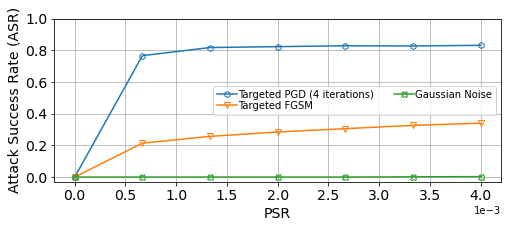

In [ ]:
plot(pdf_name='Targeted_attack_compare',
        label_dict = {

                'FGSM'          : 'Targeted FGSM',
                'PGD'         : 'Targeted PGD (4 iterations)',

                'Guassian_Noise': 'Gaussian Noise'
                },
        PGD = 'target_PGD_Rx_2_TL_3.mat',
        FGSM ='target_FGSM_Rx_2_TL_3.mat',
        Guassian_Noise ='target_GAUSSIAN_Rx_2_TL_3.mat'

        )

## Plot UAP cross environment attacks

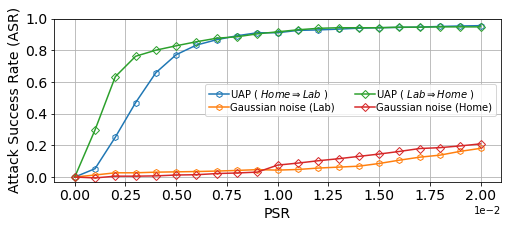

In [ ]:
from Pub_plots import *
plot(
    		pdf_name = 'Cross_domain_atk_compare',
    		label_dict = {
    				'UAP_home_to_Lab': 'UAP ( $Home \Rightarrow Lab$ )',
    				'UAP_lab_to_Home': 'UAP ( $Lab  \Rightarrow Home$ )',
    				},
    		pltGuassian = 1,
    		UAP_home_to_Lab = 'UAP_signfi_atk_home_vic_lab_scale_1_more_psr.mat',
    		UAP_lab_to_Home = 'UAP_signfi_atk_lab_vic_home_scale_1_more_psr.mat',
    		# UAP_lab_to_lab = 'UAP_signfi_lab_scale_1.mat',
    		)

# Defence

2023-10-10 16:54:47.205652: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-10-10 16:54:47.276722: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2023-10-10 16:54:47.294009: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2023-10-10 16:54:47.550703: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: li

[0.85688406 0.821558   0.8007246  0.7880435  0.7762681  0.759058
 0.7463768  0.7327899  0.7201087 ]
[0.85688406 0.8387681  0.83152175 0.82608694 0.8197464  0.8097826
 0.8043478  0.79257244 0.7871377 ]
Adversarial trained with PGD 0.08139534


<Figure size 800x600 with 0 Axes>

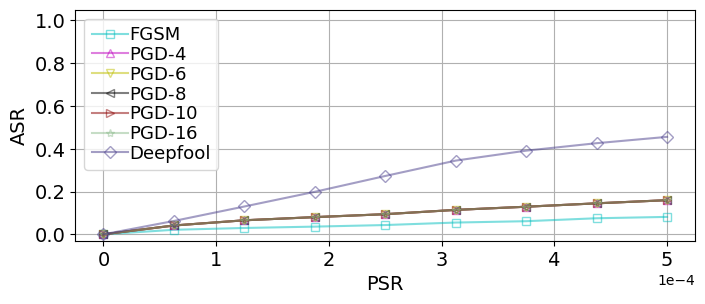

Adversarial trained with FGSM 0.060796667


<Figure size 800x600 with 0 Axes>

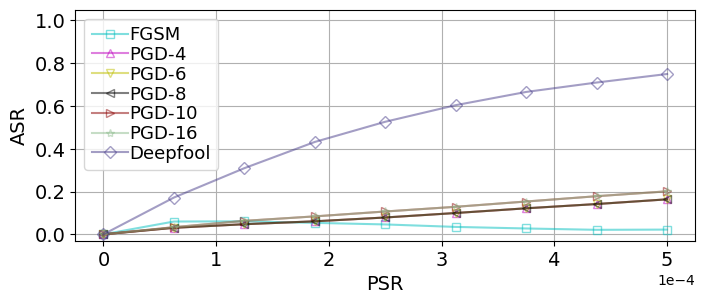

In [1]:
import utils.Config as Config
from Pub_plots import plot_adv_results
from scipy.io import loadmat
import numpy as np
config = Config.getconfig()
def dict_clean(dict):
    for key in list(dict.keys()):
        if key.startswith('__'):
            del dict[key]
    return dict
path =['resultsMat/adversarial_trainin_alex_resnet.mat','resultsMat/robust_model_against_deepfool.mat']
result = {}
for p in path:
    result.update(loadmat(p,squeeze_me=True))
result = dict_clean(result)

Defender = ['pgd','Normal']
i_DFS = 4
attacker = ['fgsm','pgd','deepfool','noise']
i_ATK = ['None',4,6,8,10,16]

# rg = np.asarray([0,7,9,10,11,12,13])
# rg = np.linspace(0,13,14,dtype=int)
rg = np.linspace(0,8,9,dtype=int)
info,legend = {},{}
info['psr'] = result['psr'][rg]
info['0'] = result['defult_pgd_4_0.001_defense_against_fgsm_None'][rg]
info['1'] = result['defult_pgd_4_0.001_defense_against_pgd_4'][rg]
info['2'] = result['defult_pgd_4_0.001_defense_against_pgd_6'][rg]
info['3'] = result['defult_pgd_4_0.001_defense_against_pgd_8'][rg]
info['4'] = result['defult_pgd_4_0.001_defense_against_pgd_10'][rg]
info['5'] = result['defult_pgd_4_0.001_defense_against_pgd_16'][rg]
info['6'] = result['defult_pgd_4_0.001_defense_against_deepfool'][rg]
print(result['defult_pgd_4_0.001_defense_against_pgd_4'][rg])
print(result['defult_pgd_4_0.001_defense_against_fgsm_None'][rg])
# info['7'] = result['defult_Normal_None_None_defense_against_fgsm_None'][rg]
leg_list = ['FGSM','PGD-$4$','PGD-$6$','PGD-$8$','PGD-$10$','PGD-$16$','Deepfool',]
for i,key in enumerate(info.keys()):
    if key == 'psr':
        continue
    legend[key] = leg_list[i - 1]
marker_dic,color_dict = {},{}
[marker_dic.update({key:marker}) for key,marker in zip(info.keys(),['o','s','^','v','<','>','*','D','+','x',])]
[color_dict.update({key:color}) for key,color in zip(info.keys(),['b','c','m','y','k','darkred','darkseagreen','darkslateblue'])]
acc = info['0']
a = ((acc[0] - acc)/acc[0])
print('Adversarial trained with PGD',np.max(a))
plot_adv_results(config,info,'Defense_perform_pgd4','asr',marker_dic = marker_dic, legend = legend,color_dic = color_dict,alpha = 0.5)
info,legend = {},{}
info['psr'] = result['psr'][rg]
info['0'] = result['defult_fgsm_None_0.001_defense_against_fgsm_None'][rg]
info['1'] = result['defult_fgsm_None_0.001_defense_against_pgd_4'][rg]
info['2'] = result['defult_fgsm_None_0.001_defense_against_pgd_6'][rg]
info['3'] = result['defult_fgsm_None_0.001_defense_against_pgd_8'][rg]
info['4'] = result['defult_fgsm_None_0.001_defense_against_pgd_10'][rg]
info['5'] = result['defult_fgsm_None_0.001_defense_against_pgd_16'][rg]
info['6'] = result['defult_fgsm_None_0.001_defense_against_deepfool'][rg]

for i,key in enumerate(info.keys()):
    if key == 'psr':
        continue
    legend[key] = leg_list[i - 1]
acc = info['0']
a = ((acc[0] - acc)/acc[0])
print('Adversarial trained with FGSM', np.max(a))
plot_adv_results(config,info,'Defense_perform_fgsm','asr',marker_dic = marker_dic, legend = legend,color_dic = color_dict,alpha = 0.5)

In [2]:
print(result['defult_fgsm_None_0.001_defense_against_fgsm_None'][rg])
print(result['defult_fgsm_None_0.001_defense_against_pgd_4'][rg])

[0.86413044 0.8125     0.8115942  0.8179348  0.8242754  0.8342391
 0.8405797  0.8460145  0.8451087 ]
[0.86413044 0.8378623  0.82336956 0.8115942  0.7961956  0.7780797
 0.759058   0.7418478  0.72282606]


## Cross-domain UAP test (defence)

2023-06-16 11:29:22.682483: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2023-06-16 11:29:22.705854: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-06-16 11:29:23.019468: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


lab to home 0.008997146 [0.         0.         0.00460829 0.00460829 0.00460829 0.00460829
 0.00460829 0.00921659 0.00921659 0.00921659 0.00921659 0.00921659
 0.00921659 0.00921659 0.01382488 0.01382488 0.01382488 0.01382488
 0.01382488 0.01382488 0.01843318]


2023-06-16 11:29:23.864214: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2023-06-16 11:29:23.881673: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2023-06-16 11:29:23.881771: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

<Figure size 576x432 with 0 Axes>

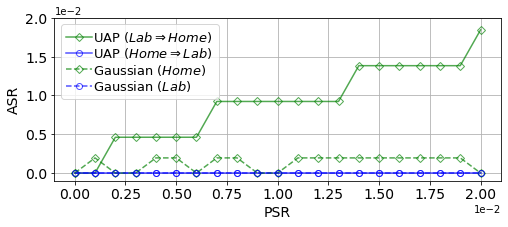

In [ ]:
import utils.Config as Config
import numpy as np
from Pub_plots import plot_adv_results
from scipy.io import loadmat
config = Config.getconfig()
def get_info_from_key(key):
    if 'Surrogate_Normal_home' not in key and 'Surrogate_Normal_lab' not in key:
        info_list = key.split('_')
        UAP_psr = float(info_list[1])
        UAP_iter = int(info_list[3])
        vic_psr = float(info_list[7])
        vic_iter = int(info_list[9])
        return UAP_psr,UAP_iter,vic_psr,vic_iter
    elif 'Surrogate_Normal_home' in key or 'Surrogate_Normal_lab' in key:
        info_list = key.split('_')
        UAP_model_name = 'Surrogate_Normal_home'
        vic_psr = float(info_list[6])
        vic_iter = int(info_list[8])
        return UAP_model_name, vic_psr, vic_iter
def get_plot_style(*args):
    marker_dic = {}
    color_dic = {}
    linstyle_dic = {}
    
    for info in args:
        # [marker_dic.update({key:marker}) for key,marker in zip(sorted(info.keys()),['o','o','o','s','s','s','^','^','^','^','^',])]
        # [color_dic.update({key:color}) for key,color in zip(sorted(info.keys()),['b','r','g','b','r','g','b','r','g',])]
        info.pop('psr',None)
        [marker_dic.update({key:marker}) for key,marker in zip(info.keys(),['D','o','D','o'])]
        [color_dic.update({key:color}) for key,color in zip(info.keys(),['g','b','g','b',])]
        [linstyle_dic.update({key:linstyle}) for key,linstyle in zip(info.keys(),['-','-','--','--',])]
    return marker_dic,color_dic,linstyle_dic
def dict_clean(dict):
    for key in list(dict.keys()):
        if key.startswith('__'):
            del dict[key]
    return dict
results = dict_clean(loadmat('resultsMat/Adversarial_training_results/UAP_Cross_domain_results_normal_surro_train_lab_to_home.mat',squeeze_me=True))
psr = np.linspace(0,2e-2,21)
legend = {}
marker_dic,color_dic = {},{}
info,info_1 = {},{}
# i = 0
for key in results.keys():
    UAP_model_name, vic_psr, vic_iter = get_info_from_key(key)
    if vic_iter == 4 and vic_psr == 0.001:
        legend[key] = 'UAP ($Lab \Rightarrow Home$)'
        info[key] = results[key].min(axis=0)
acc = info['Surrogate_Normal_lab_atk_home_PSR_0.001_iter_4']
print('lab to home',np.mean((acc[0] - acc)/acc[0]),(acc[0] - acc)/acc[0] )
results = dict_clean(loadmat('resultsMat/Adversarial_training_results/UAP_Cross_domain_results_normal_surro_train.mat',squeeze_me=True))


for key in results.keys():
    UAP_model_name, vic_psr, vic_iter = get_info_from_key(key)
    if vic_iter == 4 and vic_psr == 0.001:
        legend[key] = 'UAP ($Home \Rightarrow Lab$) '
        info_1[key] = results[key].max(axis=0)


Guassian = dict_clean(loadmat('resultsMat/Adversarial_training_results/AT_labhome_PGD_4_0.001_Gaussian.mat',squeeze_me=True))

legend['Gaussian_lab'] = 'Gaussian ($Lab$)'
legend['Gaussian_home'] = 'Gaussian ($Home$)'
to_plot = {}
to_plot.update(info)
to_plot.update(info_1)
to_plot.update(Guassian)

# to_plot = {**info,**info_1,**Guassian}
marker_dic,color_dic,linstyle= get_plot_style(to_plot)
to_plot.update({'psr':psr})
# acc = info_1['Surrogate_Normal_home_atk_lab_PSR_0.001_iter_4']
# print('Home to lab',np.mean((acc[0] - acc)/acc[0]), (acc[0] - acc)/acc[0])
plot_adv_results(config,to_plot,
                 'BB cross-domain defence subplot results',
                #  None,
                 'asr',
                 marker_dic = marker_dic, color_dic = color_dic, legend = legend, alpha = 0.68,
                 linestyle = linstyle,
                #  title = ['Home to Lab','Lab to Home'],
                 ylim = [-0.001,0.02])

## Draw loss

In [ ]:
import utils.gestureDataLoader as gestureDataLoader
import random
from ATKMethods import gen_adv_data
from sklearn.model_selection import train_test_split

from ATKMethods import AlexNetTF

random.seed(42)
config.source = 'home_276'
assert config.source != None, 'source should not be None'
train_data, test_data, train_label, test_label = gestureDataLoader.getData(
        config, 'signfi'
        )
X_train, X_test, y_train, y_test = train_test_split(train_data, train_label, test_size=0.1, random_state=42)
def draw_loss_iter(model, X, y,psr, iter_range: list):
    loss_fn = tf.keras.losses.categorical_crossentropy
    model.compile(loss=loss_fn, optimizer='adam', metrics=['accuracy'])
    loss = []
    X = X
    y = y
    for i in iter_range:
        X_adv = gen_adv_data(X,y,model,'pgd',psr,n_iter = i)
        loss.append(model.evaluate(X_adv,y,verbose=0)[0])
        # yp = model(X_adv)
        # loss.append(np.mean(loss_fn(yp, y)))
        print(f'iter {i} loss is {loss[-1]}')
    from matplotlib.lines import Line2D
    fig, ax = plt.subplots(1, 1, constrained_layout=True)
    #set figure size
    fig.set_figheight(3)
    fig.set_figwidth(5)
    ax.plot(iter_range,loss,'bo-',
            fillstyle = Line2D.fillStyles[-1],
            alpha = 0.5,
            )
    plt.xticks(np.arange(1, 21, step=2))
    plt.ylim((6,6.4))
    fig.supylabel('Loss')
    fig.supxlabel('Iteration')
    plt.grid()
    plt.savefig('RESULTS_FIGS/loss_iter.pdf')
    return loss    

# config.N_classes = 276
net = AlexNetTF( config )
model = net.buildModel( choice = 'defult' )
model.load_weights('SavedModel/Adversarial_robust_model/robust_adv_training_pgd_psr_0.001_defult_home_276_niter_4_new.h5')
loss_resnet_adv = draw_loss_iter(model, X_test, y_test, 1.2e-5, iter_range = np.linspace(1,20,20,dtype=int))


2023-06-16 11:35:44.823403: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2023-06-16 11:35:44.847054: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-06-16 11:35:45.285780: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2023-06-16 11:35:45.843414: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.

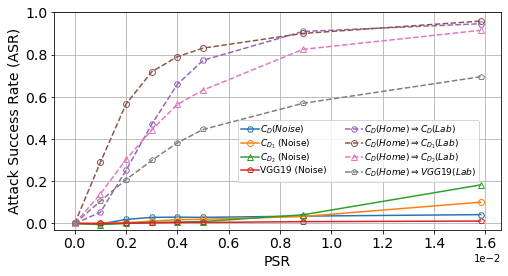

In [1]:
'''Guassian noise atk lab'''
# import loadmat
from scipy.io import loadmat
from Pub_plots import plotGuassian_noiseForModel
acc = loadmat('resultsMat/Pub_results/cross_model_test/eleven_model_test/'+'cross_model_atk_home_276_vic_lab_276_2',squeeze_me=1)
out = {}
for key,accuracy in acc.items():
	if 'atk_defult' in key:
		out[key] = accuracy

a = loadmat(
		'resultsMat/Pub_results/cross_model_test/eleven_model_test/signfi_vic_lab_276_atk_guassian_noise.mat',
		squeeze_me = 1
		)
a.update(out)
plotGuassian_noiseForModel( fname = 'Guassian_noise_lab', **a )

2023-06-16 11:43:24.335464: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2023-06-16 11:43:24.358900: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-06-16 11:43:24.682220: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2023-06-16 11:43:25.239326: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.

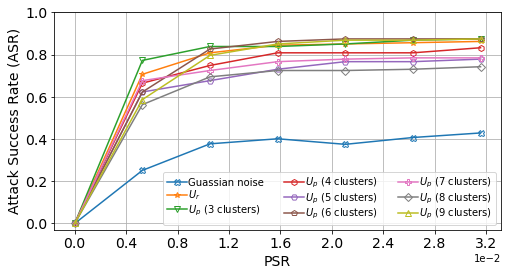

In [1]:
from Pub_plots import plot
atk_r = 5
vic_r = 4
plot(
		pdf_name = f'Oringinal_label_vs_pseudo_label_Diferent_number_of_clusters_atk_r_{atk_r}',
		pltGuassian = 0,
		Guassian_noise = f'Widar_atk_Guassian_victim_Rx{vic_r}_method_2.mat',
		marker_dict = {
				'full_label'    : '*',
				'pseudo_label_3': 'v',
				'pseudo_label_4': 'h',
				'pseudo_label_5': 'H',
				'pseudo_label_6': 'p',
				'pseudo_label_7': 'P',
				'pseudo_label_8': 'D',
				'pseudo_label_9': '^',
				'Guassian_noise': 'X',
				},
		label_dict = {
				'full_label'    : '$U_r$',
				'pseudo_label_3': '$U_p$ (3 clusters)',
				'pseudo_label_4': '$U_p$ (4 clusters)',
				'pseudo_label_5': '$U_p$ (5 clusters)',
				'pseudo_label_6': '$U_p$ (6 clusters)',
				'pseudo_label_7': '$U_p$ (7 clusters)',
				'pseudo_label_8': '$U_p$ (8 clusters)',
				'pseudo_label_9': '$U_p$ (9 clusters)',
				'Guassian_noise': 'Guassian noise',
				},
		linestyle_dict = {
				'full_label'    : '-',
				'pseudo_label_3': '--',
				'pseudo_label_4': '--',
				'pseudo_label_5': '--',
				'pseudo_label_6': '--',
				'pseudo_label_7': '--',
				'pseudo_label_8': '--',
				'pseudo_label_9': '--',
				'Guassian_noise': '-',
				},
		full_label = f'Unsupervised_labelForm_full_label_atkRx_Rx{atk_r}_vicRx_Rx{vic_r}_method_2.mat',
		pseudo_label_3 = f'Unsupervised_labelForm_pseudo_label_NClusters_3_atkRx_Rx{atk_r}_vicRx_Rx{vic_r}_method_2.mat',
		pseudo_label_4 = f'Unsupervised_labelForm_pseudo_label_NClusters_4_atkRx_Rx{atk_r}_vicRx_Rx{vic_r}_method_2.mat',
		pseudo_label_5 = f'Unsupervised_labelForm_pseudo_label_atkRx_Rx{atk_r}_vicRx_Rx{vic_r}_method_2.mat',
		pseudo_label_6 = f'Unsupervised_labelForm_pseudo_label_NClusters_6_atkRx_Rx{atk_r}_vicRx_Rx{vic_r}_method_2.mat',
		pseudo_label_7 = f'Unsupervised_labelForm_pseudo_label_NClusters_7_atkRx_Rx{atk_r}_vicRx_Rx{vic_r}_method_2.mat',
		pseudo_label_8 = f'Unsupervised_labelForm_pseudo_label_NClusters_8_atkRx_Rx{atk_r}_vicRx_Rx{vic_r}_method_2.mat',
		pseudo_label_9 = f'Unsupervised_labelForm_pseudo_label_NClusters_9_atkRx_Rx{atk_r}_vicRx_Rx{vic_r}_method_2.mat',
		)

# Confusion matrix

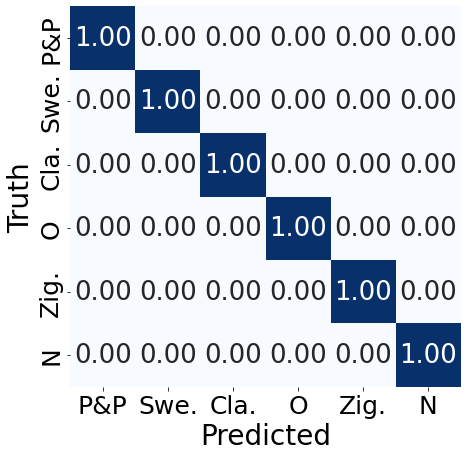

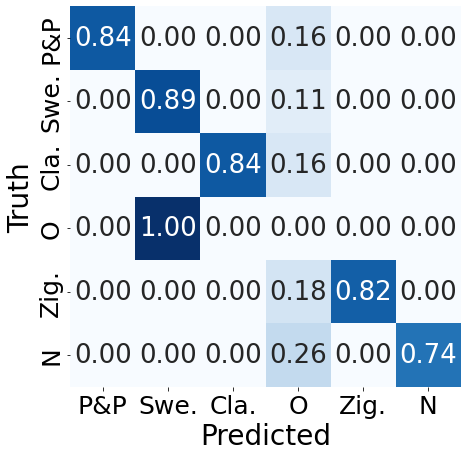

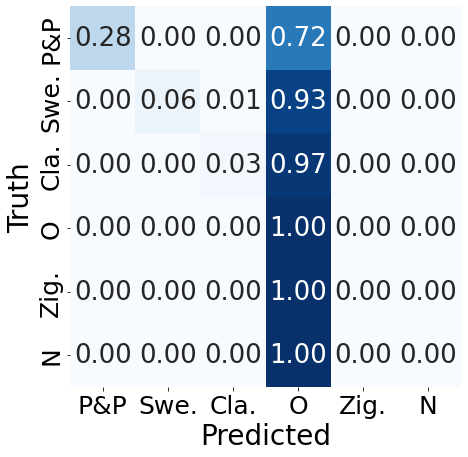

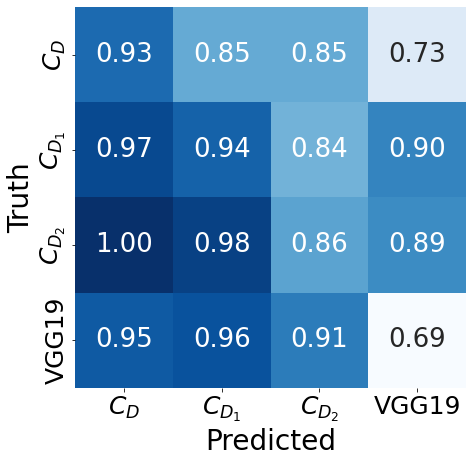

In [42]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
categories = [ 'P&P','Swe.','Cla.','O','Zig.','N' ]
model = ['$C_{D}$','$C_{D_{1}}$','$C_{D_{2}}$','VGG19',]
cf_Original_4 = np.array([
    [1.00,0.00,0.00,0.00,0.00,0.00],
    [0.00,1.00,0.00,0.00,0.00,0.00],
    [0.00,0.00,1.00,0.00,0.00,0.00],
    [0.00,0.00,0.00,1.00,0.00,0.00],
    [0.00,0.00,0.00,0.00,1.00,0.00],
    [0.00,0.00,0.00,0.00,0.00,1.00]
    ])
cf_FGSM_4 = np.array([
    [0.84,0.00,0.00,0.16,0.00,0.00,],
    [0.00,0.89,0.00,0.11,0.00,0.00,],
    [0.00,0.00,0.84,0.16,0.00,0.00,],
    [0.00,1.00,0.00,0.00,0.00,0.00,],
    [0.00,0.00,0.00,0.18,0.82,0.00,],
    [0.00,0.00,0.00,0.26,0.00,0.74,],
])
cf_PGD_4 = np.array([
    [0.28,0.00,0.00,0.72,0.00,0.00,],
    [0.00,0.06,0.01,0.93,0.00,0.00],
    [0.00,0.00,0.03,0.97,0.00,0.00],
    [0.00,0.00,0.00,1.00,0.00,0.00],
    [0.00,0.00,0.00,1.00,0.00,0.00],
    [0.00,0.00,0.00,1.00,0.00,0.00],
])
Attacker_home_Victim_model_lab_PSR= np.array([
[0.93,0.85,0.85,0.73],
[0.97,0.94,0.84,0.9],
[1.0,0.98,0.86,0.89],
[0.95,0.96,0.91,0.69]
])
def plot_confusion_matrix(categories,cm,pdf_name):
    plt.figure(figsize=(7,7))
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', annot_kws={"size": 26}, cbar=False) # Set cbar=False to remove the color bar

    plt.xticks(np.arange(len(categories))+0.5, categories, fontsize=25) # Set x-ticks
    plt.yticks(np.arange(len(categories))+0.5, categories, fontsize=25, rotation=90) # Set y-ticks

    plt.xlabel('Predicted', fontsize=28)
    plt.ylabel('Truth', fontsize=28)
    pdf_name = "RESULTS_FIGS/"+ pdf_name +'.pdf'
    plt.savefig(pdf_name,bbox_inches='tight')
    plt.show()
plot_confusion_matrix(categories,cf_Original_4,pdf_name = 'cf_Original_4')
plot_confusion_matrix(categories,cf_FGSM_4,pdf_name = 'cf_FGSM_4')
plot_confusion_matrix(categories,cf_PGD_4,pdf_name = 'cf_PGD_4')
plot_confusion_matrix(model,Attacker_home_Victim_model_lab_PSR,pdf_name = 'Attacker_home_Victim_model_lab_PSR=0.0158')

